In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import glob
import re
import numpy as np

# Determine the subthreshold electric field strength

Using a simple neuron with no synapses.

In [2]:
def plot_subthreshold_amplitude(data, phi, psi, carrier):
    dt = data[
        (data.Phi == phi) &
        (data.Psi == psi) &
        (data.Carrier == carrier) &
        (data.Offset > 0.5)
    ]
    
    dt2 = data[
        (data.Phi == phi) &
        (data.Psi == psi) &
        (data.Carrier == carrier) &
        (data.Offset > 0.5) &
        (data.Offset <= 20)
    ]
    
    fig, axs = plt.subplots(nrows = 1, ncols = 2, figsize = (12, 4))
    axs = axs.flatten()
    
    axs[0].plot(dt.Offset, dt.Amplitude, linewidth = 0.5, color = "black")
    axs[0].scatter(dt.Offset, dt.Amplitude, s = 5, color = "black")
    axs[0].set_xlabel("Offset frequency, Hz")
    axs[0].set_ylabel("Electric field amplitude, V/m")
    axs[0].grid()
    
    axs[1].plot(dt2.Offset, dt2.Amplitude, linewidth = 0.5, color = "black")
    axs[1].scatter(dt2.Offset, dt2.Amplitude, s = 5, color = "black")
    axs[1].set_xlabel("Offset frequency, Hz")
    axs[1].set_ylabel("Electric field amplitude, V/m")
    axs[1].grid()
    
    fig.suptitle(
        "Subthreshold EF amplitude\n" + fr"($\phi$ = {phi}, $\psi$ = {psi}, $f_{{\text{{carrier}}}}$ = {carrier}" +
        (", phase = 10)" if carrier != 0 else ")")
    )

In [3]:
subthreshold = []

for file in glob.glob("output/temporal-interference/ef/*_*_*.csv"):
    pattern = re.compile(r"([^/]+)_([^/]+)_([^/]+)\.csv$")
    phi, psi, carrier = pattern.search(file).groups()
    
    data = pd.read_csv(file)
    data["Phi"] = int(phi)
    data["Psi"] = int(psi)
    data["Carrier"] = int(carrier)

    subthreshold.append(data)

subthreshold = pd.concat(subthreshold, ignore_index = True)

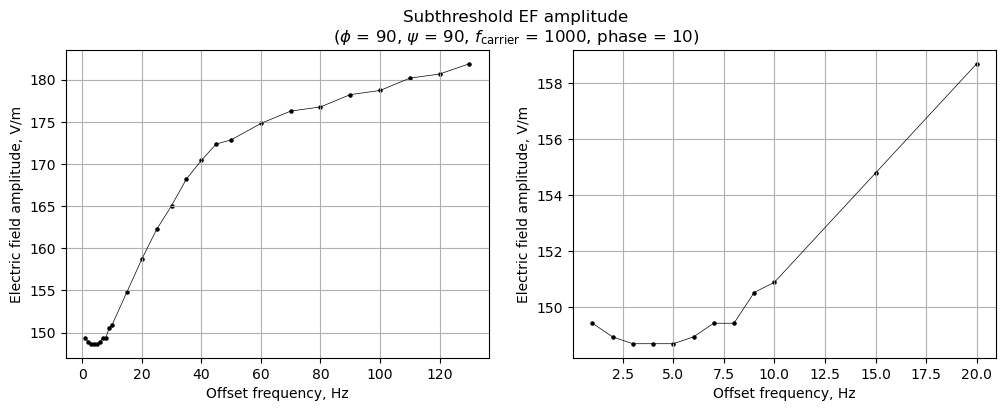

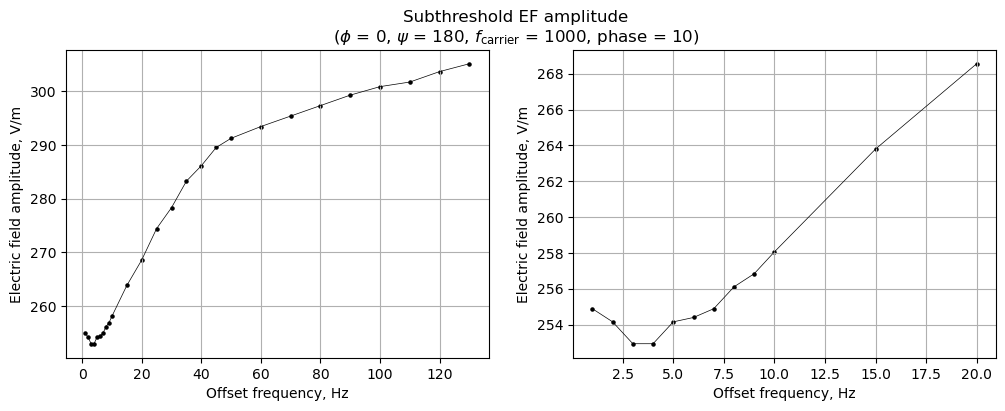

In [4]:
plot_subthreshold_amplitude(subthreshold, phi = 90, psi = 90, carrier = 1000)
plot_subthreshold_amplitude(subthreshold, phi = 0, psi = 180, carrier = 1000)

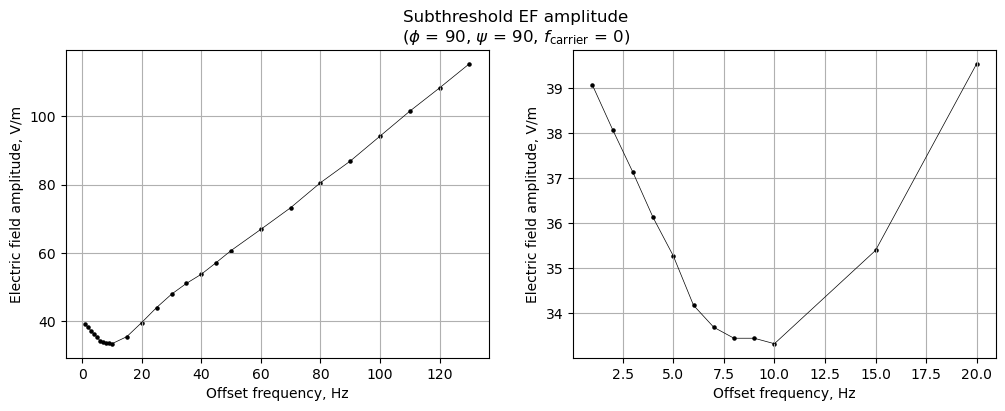

In [5]:
plot_subthreshold_amplitude(subthreshold, phi = 90, psi = 90, carrier = 0)

In [12]:
def plot_subthreshold_all(data, phi, psi, carriers = None):
    if carriers is None:
        carriers = [1000, 2000, 5000, 9000]

    for carrier in carriers:
        dt = data[
            (data.Phi == phi) &
            (data.Psi == psi) &
            (data.Carrier == carrier) &
            (data.Offset > 0.5)
        ]

        plt.plot(dt.Offset, dt.Amplitude, linewidth = 1, label = f"{carrier} Hz")
        plt.scatter(dt.Offset, dt.Amplitude, s = 10)
        plt.xlabel("Offset, Hz")
        plt.ylabel("EF amplitude, V/m")
        plt.legend()
        plt.grid()

In [6]:
def compare_subthreshold(data, carrier, ax):
    dt1 = data[
        (data.Phi == 90) &
        (data.Psi == 90) &
        (data.Carrier == carrier) &
        (data.Offset > 0.5)
    ]

    dt2 = data[
        (data.Phi == 0) &
        (data.Psi == 180) &
        (data.Carrier == carrier) &
        (data.Offset > 0.5)
    ]

    max = np.max([dt1.Amplitude.max(), dt2.Amplitude.max()])
    min = np.min([dt1.Amplitude.min(), dt2.Amplitude.min()])

    ax.plot(dt2.Offset, dt2.Amplitude, linewidth = 1, color = "tab:orange", label = rf"$\phi$ = 0, $\psi$ = 180")
    ax.scatter(dt2.Offset, dt2.Amplitude, s = 10, color = "tab:orange")

    ax.plot(dt1.Offset, dt1.Amplitude, linewidth = 1, color = "tab:blue", label = rf"$\phi$ = 90, $\psi$ = 90")
    ax.scatter(dt1.Offset, dt1.Amplitude, s = 10, color = "tab:blue")
    
    ax.set_xlabel("Offset frequency, Hz")
    ax.set_ylabel("Electric field amplitude, V/m")
    ax.set_title(rf"Subthrehold EF amplitude ($f_{{\text{{carrier}}}}$ = {carrier} Hz)")
    ax.legend(loc = "upper right")
    ax.grid()
    ax.set_ylim(min * 0.9, max * 1.2)

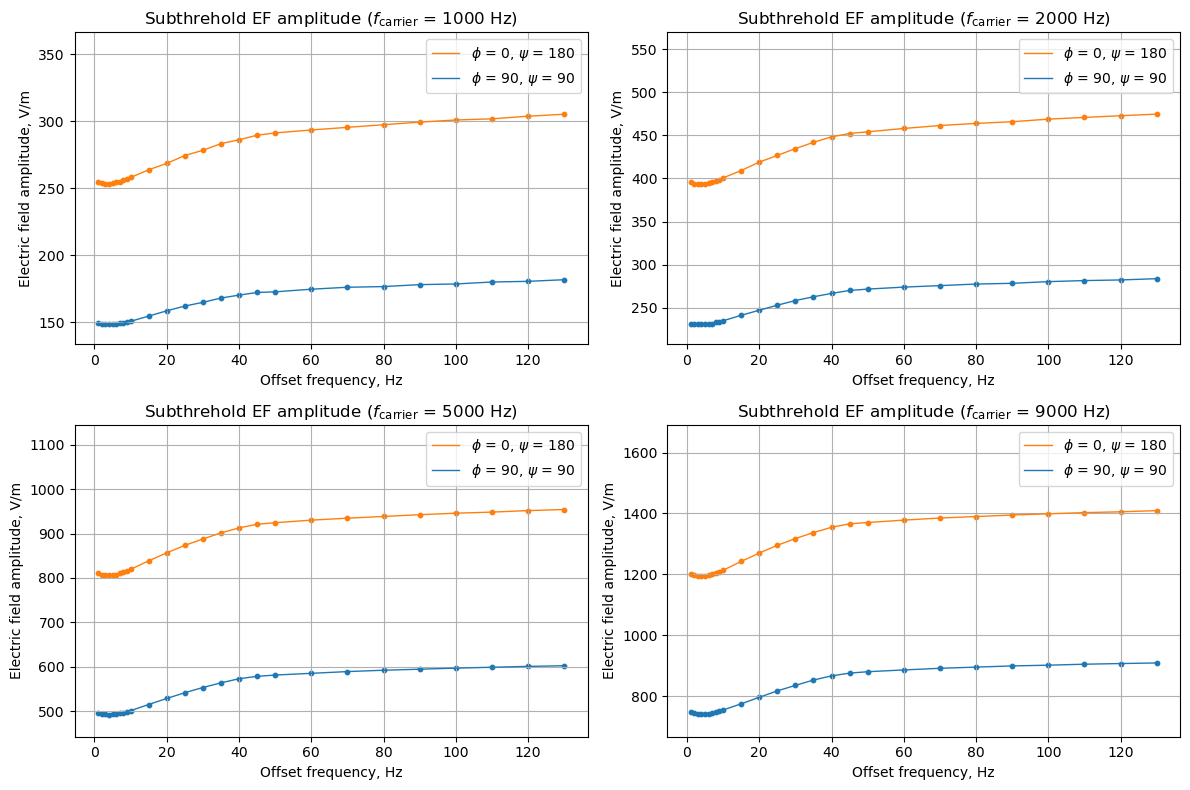

In [7]:
fig, axs = plt.subplots(nrows = 2, ncols = 2, figsize = (12, 8))
axs = axs.flatten()

compare_subthreshold(subthreshold, carrier = 1000, ax = axs[0])
compare_subthreshold(subthreshold, carrier = 2000, ax = axs[1])
compare_subthreshold(subthreshold, carrier = 5000, ax = axs[2])
compare_subthreshold(subthreshold, carrier = 9000, ax = axs[3])

fig.tight_layout()

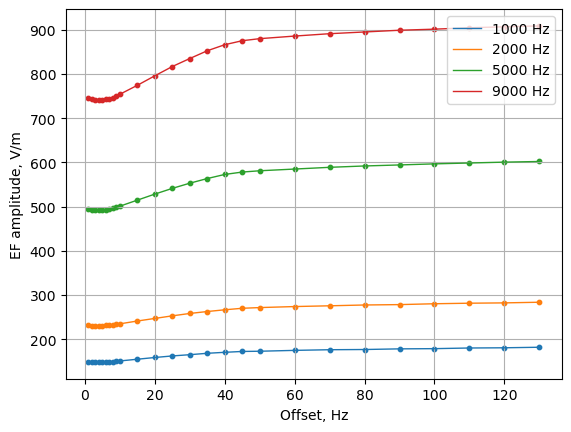

In [14]:
plot_subthreshold_all(subthreshold, phi = 90, psi = 90)
plt.grid()

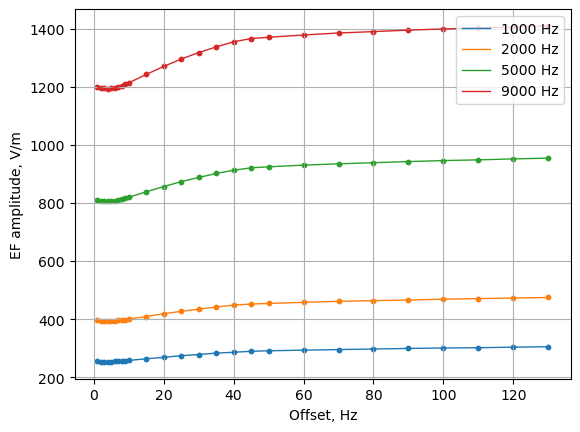

In [15]:
plot_subthreshold_all(subthreshold, phi = 0, psi = 180)
plt.grid()